In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.7
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abb

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.656 s
Baseline,off


Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
combining channels using "gfp"


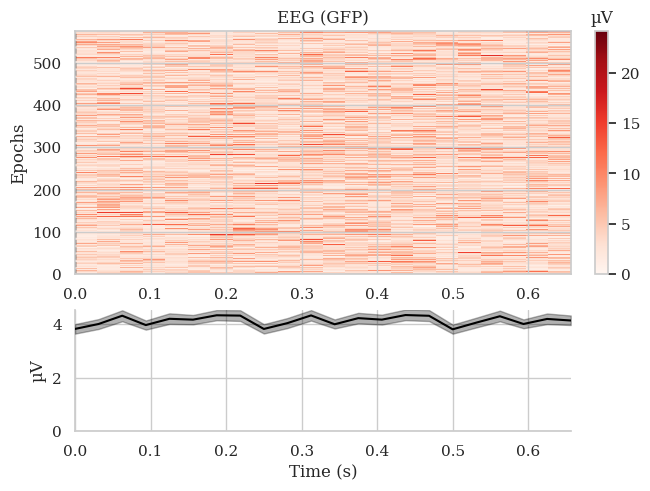

[<Figure size 640x480 with 3 Axes>]

In [4]:
epochs.plot_image()

In [5]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_2788/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 22)

In [7]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import combine_pvalues
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
    rank=8,
    max_iter=128,
    tol=1e-8,
    init ='svd',
    shrinkage='lw',
    toeplitz=None,
    obj='rt',
    solver='lanczos',
    taper=True,
    keep_train_info=True,
    verbose=True,
)


%lprun -f ledoit_wolf_shrinkage hoda.fit(X,y)
hoda

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank (8, 8) ...


HODA(keep_train_info=True, max_iter=128, rank=8, taper=True, verbose=True)

Timer unit: 1e-09 s

Total time: 0.702436 s
File: /project/src/hoda/cov.py
Function: ledoit_wolf_shrinkage at line 124

Line #      Hits         Time  Per Hit   % Time  Line Contents
   124                                           def ledoit_wolf_shrinkage(X, assume_centered=False, block_size=1000):
   125                                               """Estimate the shrunk Ledoit-Wolf covariance matrix.
   126                                               Read more in the :ref:`User Guide <shrunk_covariance>`.
   127                                               Parameters
   128                                               ----------
   129                                               X : array-like of shape (n_samples, n_features)
   130                                                   Data from which to compute the Ledoit-Wolf shrunk covariance shrinkage.
   131                                               assume_centered : bool, default=False
   132                           

In [8]:
hoda.train_info_

,F_tr,F_rt,mse,log_like,bic,aic,aicc,update
iteration,,,,,,,,
0.0,0.053443,0.008684,1.475241e-11,-74.158067,555.107025,276.316134,292.597935,1.037356e-01
1.0,0.046498,0.009671,1.132965e-11,-62.334470,531.459830,252.668940,268.950740,9.609278e-02
2.0,0.066183,0.009658,1.341135e-11,-62.649905,532.090699,253.299809,269.581610,8.540201e-02
3.0,0.053221,0.009939,1.239875e-11,-59.873872,526.538634,247.747744,264.029544,8.175258e-02
4.0,0.063719,0.009688,1.358641e-11,-72.805183,552.401256,273.610366,289.892166,7.635822e-02
5.0,0.056334,0.009924,1.305527e-11,-61.923135,530.637160,251.846269,268.128070,8.496719e-02
6.0,0.060155,0.009761,1.360363e-11,-66.034177,538.859244,260.068354,276.350154,8.228497e-02
7.0,0.058334,0.009911,1.335112e-11,-59.439613,525.670117,246.879227,263.161027,7.870136e-02
8.0,0.058859,0.009849,1.360576e-11,-63.410004,533.610898,254.820008,271.101808,9.369384e-02


In [9]:
hoda.mode_train_info_

objective  shrinkage  rank        update
iteration mode                                             
0.0       0.0   4.784227e+09   0.000879   8.0  1.276743e-01
          1.0   6.013995e+07   0.047585   8.0  8.428533e-02
1.0       0.0   8.137678e+09   0.000961   8.0  1.378637e-01
          1.0   2.675518e+10   0.048494   8.0  6.697789e-02
2.0       0.0   8.871329e+09   0.000849   8.0  1.518527e-01
...                      ...        ...   ...           ...
49.0      1.0   5.213455e+10   0.037433   8.0  2.768997e-08
50.0      0.0   9.950310e+09   0.001084   8.0  1.024125e-08
          1.0   5.213005e+10   0.037438   8.0  1.629759e-08
51.0      0.0   9.950619e+09   0.001084   8.0  5.107254e-09
          1.0   5.213382e+10   0.037434   8.0  1.158794e-08

[104 rows x 4 columns]

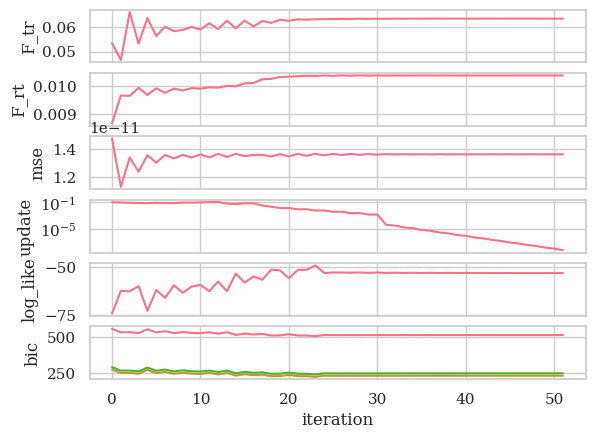

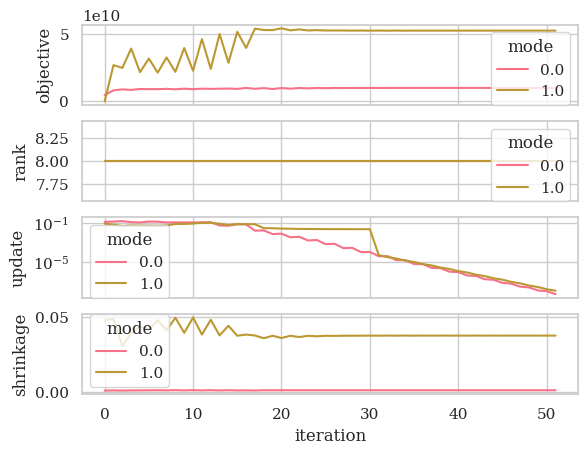

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(6,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', ax=axs[2])
    #axs[2].set(yscale="log")
    #axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='log_like', ax=axs[4])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='bic', ax=axs[5])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aic', ax=axs[5])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aicc', ax=axs[5])

    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[3])


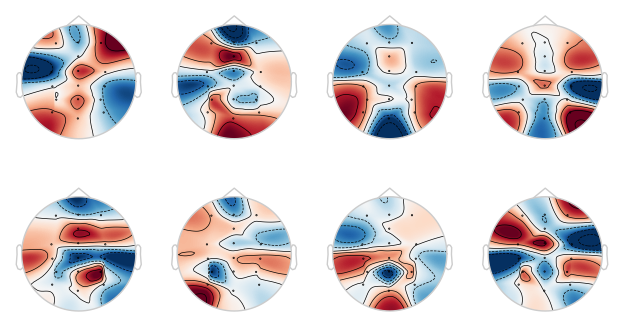

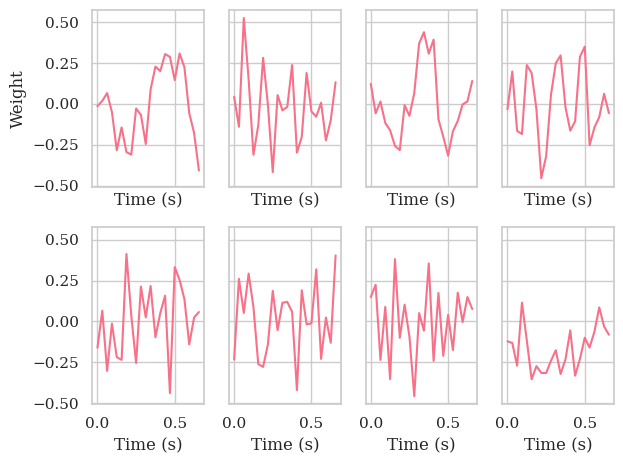

In [11]:

import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.weights_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


In [12]:
hoda.aps_

[array([[ 0.09493225, -0.05798158, -0.02240788,  0.08294221,  0.07542464,
          0.01710367, -0.00725958, -0.13959604],
        [ 0.12345094, -0.05224011,  0.05639244,  0.02864889,  0.11822329,
         -0.00449248,  0.03328179, -0.12204045],
        [ 0.10527552,  0.01975876,  0.096208  , -0.03321336,  0.02695601,
         -0.02039762, -0.03303004, -0.13521937],
        [ 0.07944674,  0.09958859,  0.05435794, -0.03554843,  0.02258951,
         -0.01850139,  0.0289286 , -0.07107089],
        [ 0.09520292,  0.02459702,  0.09291231, -0.01295764, -0.0106814 ,
         -0.08403416,  0.08064675, -0.11605579],
        [ 0.07529664,  0.0242876 ,  0.11392901, -0.02871414,  0.04584157,
          0.062696  , -0.04084227, -0.10459313],
        [ 0.08329746,  0.07439904,  0.08104856, -0.00515526, -0.04308417,
         -0.02385142,  0.08391392, -0.04224176],
        [ 0.04438862,  0.07165446,  0.10030808,  0.03074486,  0.05630577,
          0.02539073, -0.04952221, -0.08298981],
        [ 0.0743

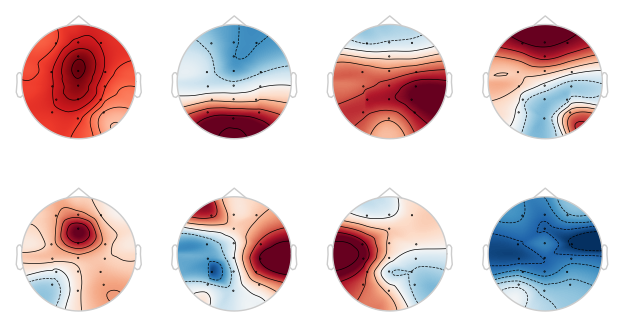

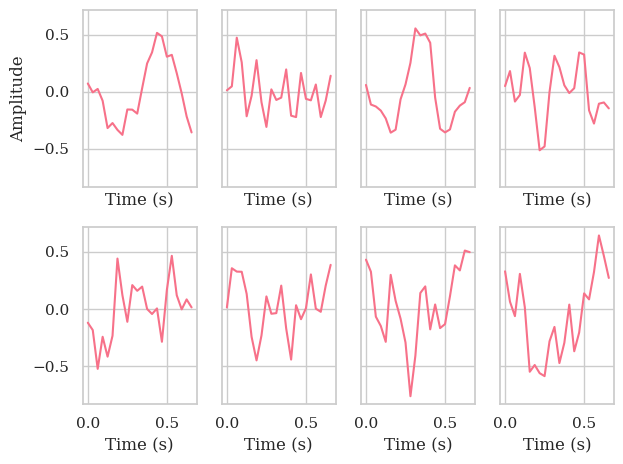

In [13]:

n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


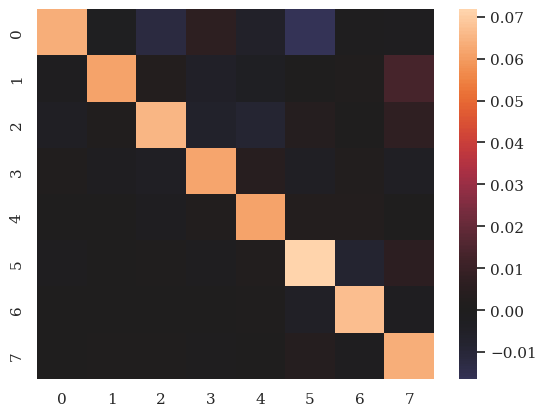

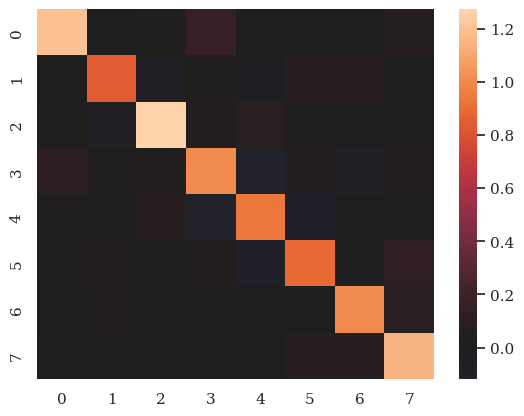

In [14]:
for k in range(2):
    sns.heatmap(tl.to_numpy(hoda.weights_[k].T@ hoda.aps_[k]), center=0)
    plt.show()


In [15]:
Xt = hoda.transform(X)

[[6.67868661e-02 3.99121851e-01 4.42870779e-10 6.22445932e-02
  1.74698359e-04 5.62444404e-02 3.43507844e-01 7.57766711e-01]
 [5.33087759e-01 7.13499991e-03 9.74765182e-01 2.22411550e-01
  3.47110328e-10 2.65584385e-09 3.86363113e-01 2.15684179e-22]
 [1.03203473e-22 4.01281552e-01 1.18622355e-33 1.61953970e-01
  1.95709518e-02 6.35820344e-04 1.26230872e-07 6.74815176e-01]
 [8.94241195e-05 1.40837842e-05 7.12857250e-03 6.21882667e-02
  1.70779440e-03 2.34061377e-19 4.71093246e-02 2.38934020e-11]
 [1.41069607e-06 1.37599623e-04 4.29574540e-03 1.53935195e-18
  9.71698819e-01 4.64453962e-01 3.45681613e-01 3.85883957e-01]
 [2.35432343e-09 4.18332604e-03 9.64032805e-01 6.52976645e-03
  2.75746344e-02 5.11984885e-02 3.78092014e-01 4.43655926e-02]
 [2.46784308e-04 5.38543995e-02 1.96962832e-04 8.50775945e-01
  2.13193467e-01 1.33802848e-05 3.70144774e-01 9.64570267e-03]
 [5.33774343e-01 3.45408403e-01 5.34310778e-01 1.45677593e-01
  7.19583239e-03 6.15976777e-01 7.15380142e-09 2.50349300e-01]]

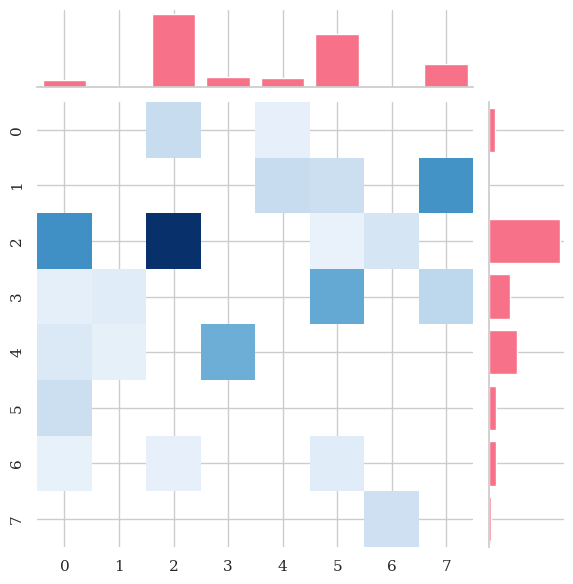

In [16]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)

print(p)
print()
print(p_sp)
print()
print(p_tmp)

In [17]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(576, 64)

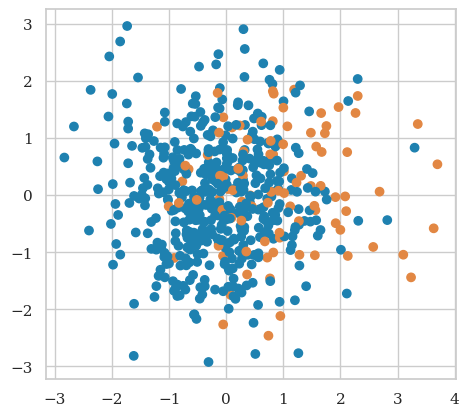

In [18]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


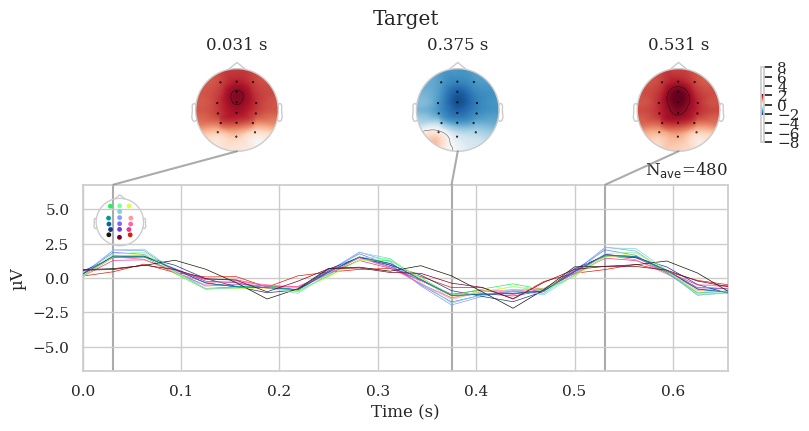

No projector specified for this dataset. Please consider the method self.add_proj.


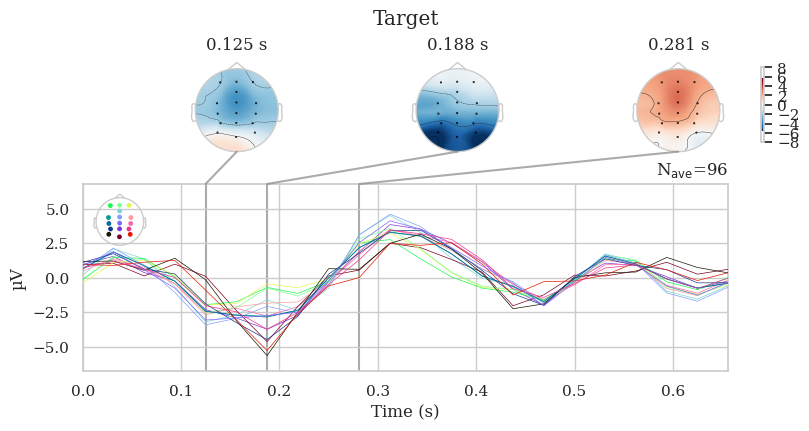

In [19]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_2788/286715887.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


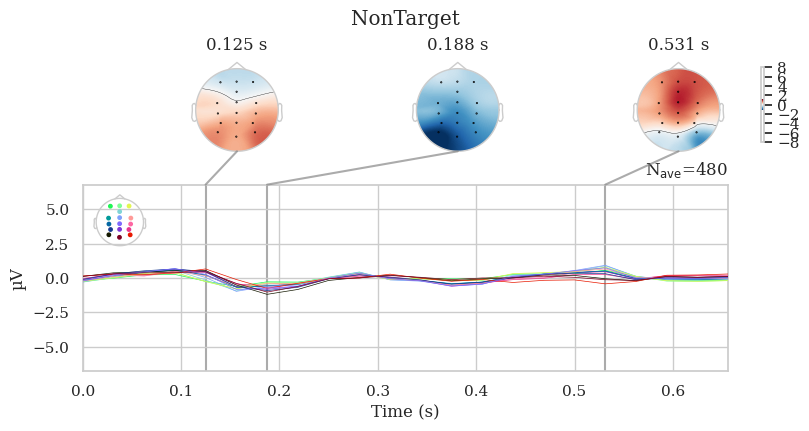

No projector specified for this dataset. Please consider the method self.add_proj.


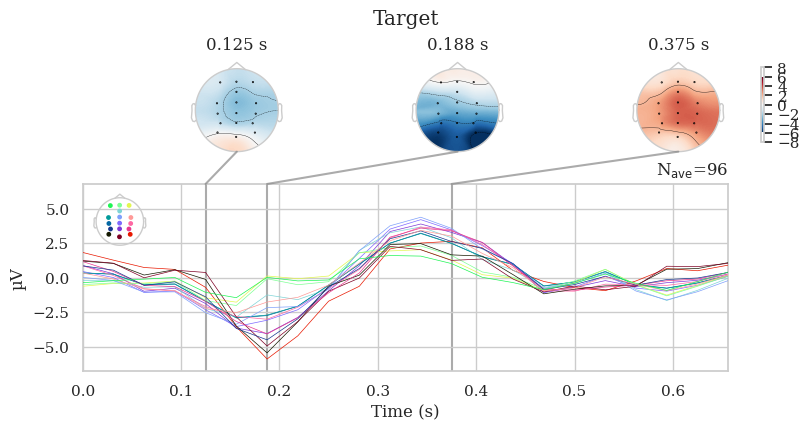

In [20]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,**joint_args)
    else:
        evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


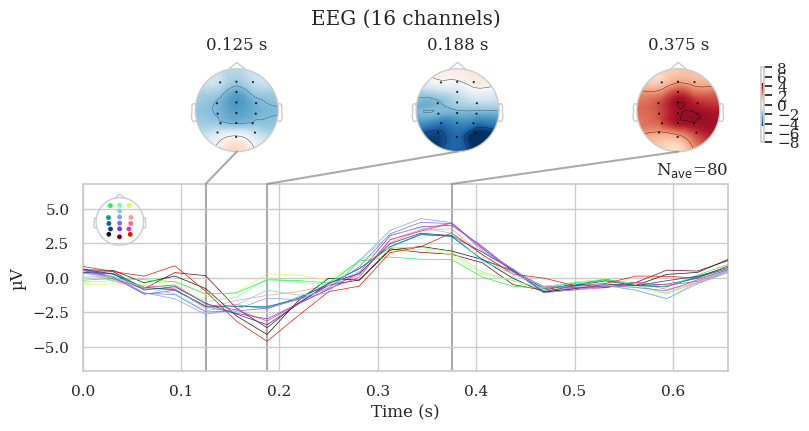

No projector specified for this dataset. Please consider the method self.add_proj.


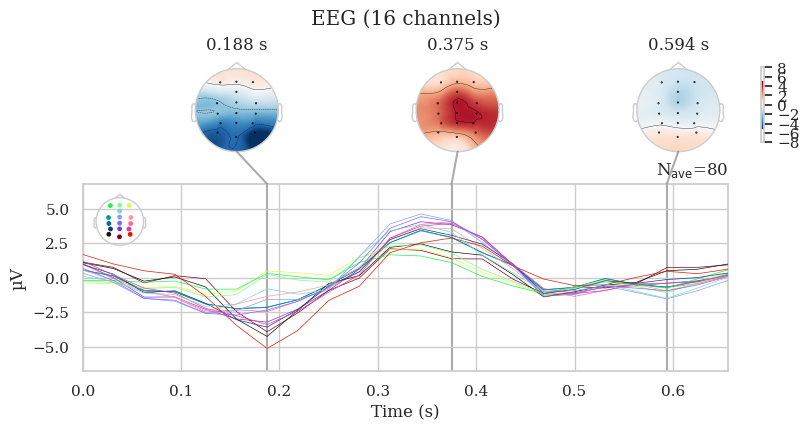

In [21]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


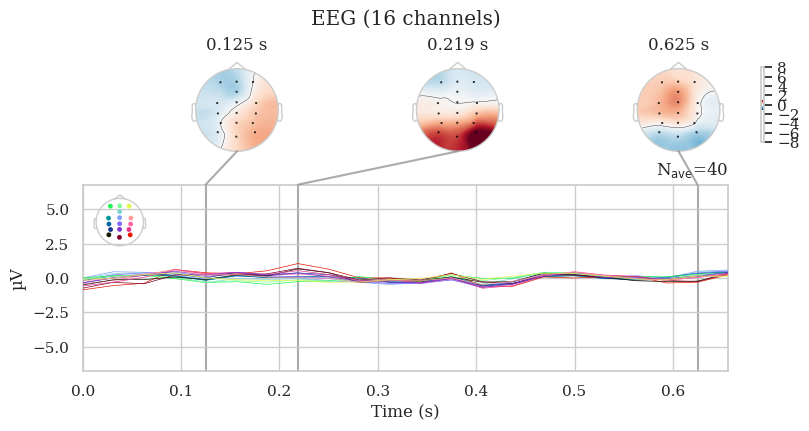

In [22]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)